# Formula 1  Anomaly Detection

<div style="
  display: flex;
  justify-content: center;
  gap: 32px;
  margin: 20px 0;
">
  <img src="images/pexels-jonathanborba-29406740.jpg" style="width: 40%; border-radius: 4px;" />
</div>

## Project Overview

**Formula 1 is a sport of precision.**  
Most races follow highly regular patterns — lap times are tightly clustered, pit stops are strategically planned, and race outcomes tend to fall within expected performance ranges.

Yet, every season contains moments that break this order: sudden crashes, mechanical failures, extreme weather, safety car interventions, or unconventional race strategies that disrupt the normal flow of a race.

This project explores whether such **irregular race events can be detected automatically using data alone**.

By applying **unsupervised anomaly detection techniques** to historical Formula 1 data, the project aims to identify races and driver performances that deviate significantly from what is considered “normal”, **without relying on predefined anomaly labels**.

This type of analysis is highly relevant in modern Formula 1, where teams increasingly rely on data-driven systems to monitor performance, detect unexpected behavior, and react quickly to abnormal race conditions. Automatically flagging unusual races or driver performances can support:

- Early detection of performance degradation or mechanical issues  
- Identification of races affected by external disruptions (e.g., safety cars, weather)  
- Post-race analysis of strategic anomalies and edge-case scenarios  
- Validation of whether extreme outcomes are explainable or truly unexpected  

Rather than predicting winners or lap times, the focus is on **pattern discovery and interpretability** — uncovering unusual behaviors in the data and validating whether they correspond to real-world race incidents.

---

## Problem Statement

In real Formula 1 data, **anomalies are not explicitly labeled**.  
Events such as DNFs, extreme lap times, or atypical pit stop behavior must be inferred from data patterns rather than known in advance.

The core problem addressed in this project is:

> **How can we automatically detect abnormal races or driver performances in Formula 1 using data alone, without labeled anomalies?**

This makes the problem well-suited for **unsupervised learning**, where models learn what is “normal” and flag deviations from that norm.

---

## Solution

To address this problem, we use a combination of:

- **Feature aggregation** to summarize race and driver behavior  
- **Exploratory Data Analysis** (EDA) to understand normal patterns and variability  
- Unsupervised anomaly detection models, including:
  - **Principal Component Analysis** (PCA)
  - **Isolation Forest**  
- **Percentile-based thresholds** to identify the most extreme cases  
- **Post-hoc validation** using race outcomes

By comparing multiple models and validating anomalies against known race events, we aim to ensure that detected anomalies are **interpretable and meaningful**, not just statistical outliers.

---

## Project Workflow

This notebook follows a complete unsupervised machine learning pipeline:

1. Dataset understanding and domain context  
2. Data cleaning and preprocessing  
3. Feature engineering and aggregation  
4. Exploratory Data Analysis (EDA)  
5. Anomaly detection modeling  
6. Model comparison and thresholding  
7. Post-hoc validation and interpretation  
8. Final insights

Each step is designed to progressively move from raw data to validated insights.

---

## Datasets Used

This project uses data from the **Ergast Developer API**, a widely used public API that provides comprehensive historical Formula 1 data.

The Ergast API contains structured datasets covering Formula 1 seasons from **1950 to 2024**, including detailed information on:

- Races and seasons (year, round, circuit, date)
- Drivers and constructors
- Driver participation per race
- Lap times
- Pit stop events and durations
- Race results and finishing status

Although the full dataset spans multiple decades, **the anomaly detection models in this project are trained and evaluated only on data from the 2015–2024 seasons**.

This restriction is applied to ensure:
- Greater data consistency, as modern Formula 1 regulations, car technology, and race formats are more stable in recent seasons
- Reduced structural shifts caused by major historical rule changes
- More reliable definition of “normal” race behavior for unsupervised learning

The full historical data is still useful for contextual understanding, but focusing on recent seasons allows the models to learn patterns that are relevant to the current era of Formula 1.

All datasets are merged and transformed into **driver–race level aggregated features**, which form the final input for anomaly detection models.


---

## Key Objective

The primary objective of this project is not model accuracy, but **insight discovery**:

- Identify races and driver performances that significantly deviate from normal behavior  
- Understand *why* these anomalies occur  
- Validate whether detected anomalies align with real Formula 1 events  
- Demonstrate a reliable, interpretable unsupervised machine learning workflow


## Formula 1 Terminology

To improve readability for readers who may not be deeply familiar with Formula 1, a few commonly used terms are briefly explained below:

- **DNF (Did Not Finish):** A driver who fails to complete the race, often due to crashes or mechanical failures  
- **Pit Stop:** A planned stop during the race to change tires, repair damage, or make adjustments  
- **Safety Car:** A car deployed on track to slow the race due to an accident or hazardous conditions  
- **Lap Time:** The time taken by a driver to complete one full lap of the circuit  
- **Grid Position:** The starting position of a driver at the beginning of the race  
- **Race Status:** The final classification of a driver (e.g., finished, DNF, disqualified)


## Phase 1 - Data Understanding and Inspect

### Step 1 – Setup and Data Loading

In this step, we import the required Python libraries and load the raw Formula 1 datasets from the Ergast Developer API into pandas DataFrames. The datasets are stored in a dictionary for convenient access throughout the notebook.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import io

# Load datasets
races = pd.read_csv("data/races.csv")
races = pd.DataFrame(races)

results = pd.read_csv("data/results.csv")
results = pd.DataFrame(results)

lap_times = pd.read_csv("data/lap_times.csv")
lap_times = pd.DataFrame(lap_times)

pit_stops = pd.read_csv("data/pit_stops.csv")
pit_stops = pd.DataFrame(pit_stops)

status = pd.read_csv("data/status.csv")
status = pd.DataFrame(status)

drivers = pd.read_csv("data/drivers.csv")
drivers = pd.DataFrame(drivers)

# Store datasets in a dictionary for easier access
datasets = {
    "races": races,
    "results": results,
    "drivers": drivers,
    "status": status,
    "lap_times": lap_times,
    "pit_stops": pit_stops
}

### Step 2 – Initial Data Inspection

In this step, we inspect each dataset by reviewing its shape and a small preview of the data. This helps verify that the datasets were loaded correctly and provides an initial understanding of their structure.


In [2]:
for name, df in datasets.items():
    print(f"\nDataset: {name}")
    print(f"Shape: {df.shape}")
    display(df.head())


Dataset: races
Shape: (1125, 18)


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N



Dataset: results
Shape: (26759, 18)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1



Dataset: drivers
Shape: (861, 9)


...

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine



Dataset: lap_times
Shape: (589081, 6)


,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342



Dataset: pit_stops
Shape: (11371, 7)


,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842


### Step 3 – Dataset Structure and Data Types
In this step, we examine the structure of each dataset using `DataFrame.info()`. This allows us to inspect column names, data types, non-null counts, and memory usage in a compact and readable format.


In [3]:
infos = []

for name, df in datasets.items():
    buffer = io.StringIO()
    df.info(buf=buffer)
    info_str = buffer.getvalue()
    
    infos.append((name, info_str))

html = "<div style='display:grid; grid-template-columns:1fr 1fr; gap:20px;'>"

for name, info in infos:
    html += f"""
    <div style="border:1px solid #e5e7eb; padding:10px; border-radius:8px;">
        <h4>Dataset: {name}</h4>
        <pre style="font-size:12px; white-space:pre-wrap;">{info}</pre>
    </div>
    """

html += "</div>"

display(HTML(html))


<h3>Understanding the Features</h3>

<table style="width:100%; border-spacing:20px;">
<tr>
<td style="vertical-align:top; width:50%;">

<h4>Dataset: races</h4>

<table>
<thead>
<tr><th>Feature Name</th><th>Description</th></tr>
</thead>
<tbody>
<tr><td><code>raceId</code></td><td>Unique identifier for each Formula 1 race.</td></tr>
<tr><td><code>year</code></td><td>Season year in which the race took place.</td></tr>
<tr><td><code>round</code></td><td>Round number of the race within the season.</td></tr>
<tr><td><code>circuitId</code></td><td>Identifier of the circuit where the race was held.</td></tr>
<tr><td><code>name</code></td><td>Official name of the Grand Prix.</td></tr>
<tr><td><code>date</code></td><td>Date on which the race was held.</td></tr>
<tr><td><code>time</code></td><td>Start time of the race (local time).</td></tr>
<tr><td><code>url</code></td><td>URL linking to the race information page.</td></tr>
<tr><td><code>fp1_date</code></td><td>Date of the first free practice session.</td></tr>
<tr><td><code>fp1_time</code></td><td>Start time of the first free practice session.</td></tr>
<tr><td><code>fp2_date</code></td><td>Date of the second free practice session.</td></tr>
<tr><td><code>fp2_time</code></td><td>Start time of the second free practice session.</td></tr>
<tr><td><code>fp3_date</code></td><td>Date of the third free practice session.</td></tr>
<tr><td><code>fp3_time</code></td><td>Start time of the third free practice session.</td></tr>
<tr><td><code>quali_date</code></td><td>Date of the qualifying session.</td></tr>
<tr><td><code>quali_time</code></td><td>Start time of the qualifying session.</td></tr>
<tr><td><code>sprint_date</code></td><td>Date of the sprint race (if applicable).</td></tr>
<tr><td><code>sprint_time</code></td><td>Start time of the sprint race.</td></tr>
</tbody>
</table>

</td>

<td style="vertical-align:top; width:50%;">

<h4>Dataset: results</h4>

<table>
<thead>
<tr><th>Feature Name</th><th>Description</th></tr>
</thead>
<tbody>
<tr><td><code>resultId</code></td><td>Unique identifier for each race result entry.</td></tr>
<tr><td><code>raceId</code></td><td>Identifier of the race.</td></tr>
<tr><td><code>driverId</code></td><td>Identifier of the driver.</td></tr>
<tr><td><code>constructorId</code></td><td>Identifier of the constructor (team).</td></tr>
<tr><td><code>number</code></td><td>Car number assigned to the driver (may be missing for older seasons).</td></tr>
<tr><td><code>grid</code></td><td>Starting grid position.</td></tr>
<tr><td><code>position</code></td><td>Finishing position as a string (can be non-numeric in some cases).</td></tr>
<tr><td><code>positionText</code></td><td>Text representation of the finishing position or status.</td></tr>
<tr><td><code>positionOrder</code></td><td>Numeric finishing position used for ordering (clean numeric form).</td></tr>
<tr><td><code>points</code></td><td>Points scored by the driver in the race.</td></tr>
<tr><td><code>laps</code></td><td>Number of laps completed by the driver.</td></tr>
<tr><td><code>time</code></td><td>Total race time as a string (e.g., <code>1:32:45.123</code>) when available.</td></tr>
<tr><td><code>milliseconds</code></td><td>Total race time in milliseconds (often missing for older seasons).</td></tr>
<tr><td><code>fastestLap</code></td><td>Lap number on which the driver set their fastest lap (if available).</td></tr>
<tr><td><code>rank</code></td><td>Rank of the fastest lap relative to other drivers in the race (if available).</td></tr>
<tr><td><code>fastestLapTime</code></td><td>Fastest lap time recorded by the driver (string format) when available.</td></tr>
<tr><td><code>fastestLapSpeed</code></td><td>Speed during the fastest lap (string/decimal format) when available.</td></tr>
<tr><td><code>statusId</code></td><td>Identifier indicating race completion status (e.g., Finished, Accident, Engine).</td></tr>
</tbody>
</table>


</td>
</tr>
</table>


<table style="width:100%; border-spacing:20px;">
<tr>

<td style="vertical-align:top; width:50%;">

<h4>Dataset: drivers</h4>

<table>
<thead>
<tr><th>Feature Name</th><th>Description</th></tr>
</thead>
<tbody>
<tr><td><code>driverId</code></td><td>Unique identifier for each driver.</td></tr>
<tr><td><code>driverRef</code></td><td>Short reference name for the driver.</td></tr>
<tr><td><code>number</code></td><td>Permanent driver number.</td></tr>
<tr><td><code>code</code></td><td>Three-letter driver code.</td></tr>
<tr><td><code>forename</code></td><td>First name of the driver.</td></tr>
<tr><td><code>surname</code></td><td>Last name of the driver.</td></tr>
<tr><td><code>dob</code></td><td>Date of birth of the driver.</td></tr>
<tr><td><code>nationality</code></td><td>Nationality of the driver.</td></tr>
<tr><td><code>url</code></td><td>URL linking to the profile page of the driver.</td></tr>
</tbody>
</table>

</td>

<td style="vertical-align:top; width:50%;">

<h4>Dataset: status</h4>

<table>
<thead>
<tr><th>Feature Name</th><th>Description</th></tr>
</thead>
<tbody>
<tr><td><code>statusId</code></td><td>Unique identifier for each race status type.</td></tr>
<tr><td><code>status</code></td><td>Text description of the race outcome or failure (e.g., Finished, Accident, Engine).</td></tr>
</tbody>
</table>

</td>

</tr>
</table>


<table style="width:100%; border-spacing:20px;">
<tr>

<td style="vertical-align:top; width:50%;">

<h4>Dataset: lap_times</h4>

<table>
<thead>
<tr><th>Feature Name</th><th>Description</th></tr>
</thead>
<tbody>
<tr><td><code>raceId</code></td><td>Identifier of the race.</td></tr>
<tr><td><code>driverId</code></td><td>Identifier of the driver.</td></tr>
<tr><td><code>lap</code></td><td>Lap number within the race.</td></tr>
<tr><td><code>position</code></td><td>Position of the driver at the end of the lap.</td></tr>
<tr><td><code>time</code></td><td>Lap time recorded as a string (MM:SS.ms).</td></tr>
<tr><td><code>milliseconds</code></td><td>Lap time expressed in milliseconds.</td></tr>
</tbody>
</table>

</td>

<td style="vertical-align:top; width:50%;">

<h4>Dataset: pit_stops</h4>

<table>
<thead>
<tr><th>Feature Name</th><th>Description</th></tr>
</thead>
<tbody>
<tr><td><code>raceId</code></td><td>Identifier of the race.</td></tr>
<tr><td><code>driverId</code></td><td>Identifier of the driver.</td></tr>
<tr><td><code>stop</code></td><td>Sequential number of the pit stop during the race.</td></tr>
<tr><td><code>lap</code></td><td>Lap on which the pit stop occurred.</td></tr>
<tr><td><code>time</code></td><td>Time of day when the pit stop occurred.</td></tr>
<tr><td><code>duration</code></td><td>Duration of the pit stop (string format).</td></tr>
<tr><td><code>milliseconds</code></td><td>Duration of the pit stop in milliseconds.</td></tr>
</tbody>
</table>

</td>

</tr>
</table>


## Step 4 – Column Renaming
In this step, some column names are renamed to more descriptive ones, making the data easier to interpret and reducing confusion during later analysis and feature engineering.

In [4]:
rename_maps = {

    "pit_stops": {
        "stop": "stop_number",
        "lap": "pit_stop_lap",
        "time": "pit_stop_time",
        "duration": "pit_stop_duration",
        "milliseconds": "pit_stop_ms"
    },

    "lap_times": {
        "position": "position_after_lap",
        "time": "lap_time_str",
        "milliseconds": "lap_time_ms"
    },

    "drivers": {
        "number": "driver_number",
        "code": "driver_code",
        "forename": "first_name",
        "dob": "date_of_birth",
        "url": "driver_url"
    },

    "races": {
        "name": "race_name",
        "time": "start_time",
        "url": "race_url"
    },

    "results": {
        "number": "car_number",
        "grid": "starting_grid_position",
        "laps": "completed_laps",
        "time": "total_race_time",
        "position": "finish_position_str",
        "positionText": "finish_status_text",
        "positionOrder": "finish_position",
        "milliseconds": "race_time_ms",
        "fastestLapTime": "fastest_lap_time",
        "fastestLapSpeed": "fastest_lap_speed"
    }

}

for name, df in datasets.items():
    if name in rename_maps:
        df.rename(columns=rename_maps[name], inplace=True)
        print(f" Renamed columns for dataset: {name}")
    else:
        print(f" No renames defined for dataset: {name}")

 Renamed columns for dataset: races
 Renamed columns for dataset: results
 Renamed columns for dataset: drivers
 No renames defined for dataset: status
 Renamed columns for dataset: lap_times
 Renamed columns for dataset: pit_stops


## Step 5 – Column Types and Data Type Distribution
In this step, we examine the data types of all columns across datasets. This provides a clear overview of how each variable is represented and highlights potential inconsistencies that may require conversion before feature engineering or modeling.


In [5]:
from IPython.display import display, HTML
import pandas as pd

blocks = []

for name, df in datasets.items():
    # Column types table
    column_types = pd.DataFrame({
        "column_name": df.columns,
        "data_type": df.dtypes.values
    }).to_html(index=False)
    
    # Data type summary
    dtype_summary = (
        df.dtypes.value_counts()
        .rename("count")
        .to_frame()
        .to_html()
    )
    
    block = f"""
    <div style="border:1px solid #e5e7eb; padding:12px; border-radius:8px;">
        <h4>Dataset: {name}</h4>
        <h5>Column Types</h5>
        {column_types}
        <h5>Data Types Summary</h5>
        {dtype_summary}
    </div>
    """
    
    blocks.append(block)

html = """
<div style="
    display:grid;
    grid-template-columns: 1fr 1fr;
    gap:20px;
">
""" + "".join(blocks) + "</div>"

display(HTML(html))


column_name,data_type
raceId,int64
year,int64
round,int64
circuitId,int64
race_name,object
date,object
start_time,object
race_url,object
fp1_date,object
fp1_time,object


## Step 6 – Data Quality Checks

### Missing Values

In this step, we examine the presence of missing values across all datasets by computing both the absolute count and percentage of missing entries per column. This helps identify fields that may require cleaning, imputation, or special handling in later stages of the project.


In [6]:
for name, df in datasets.items():
    print(f"\nMissing Values — {name}")
    
    missing_table = (
        pd.DataFrame({
            "Missing Count": df.isna().sum(),
            "Missing %": (df.isna().mean() * 100).round(2)
        })
        .query("`Missing %` > 0")
        .sort_values("Missing %", ascending=False)
    )
    
    if missing_table.empty:
        print("No missing values")
    else:
        display(missing_table)


Missing Values — races
No missing values

Missing Values — results
No missing values

Missing Values — drivers
No missing values

Missing Values — status
No missing values

Missing Values — lap_times
No missing values

Missing Values — pit_stops
No missing values


### Duplicate Rows

In this step, we check each dataset for duplicate rows to ensure data integrity. Duplicate records can bias aggregations and distort anomaly detection results, so confirming their absence (or presence) is an important validation step before preprocessing.


In [7]:
for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    
    if dup_count == 0:
        print(f"\n Duplicates — {name}: No duplicate rows")
    else:
        print(f"\n Duplicates — {name}: {dup_count} duplicate rows found")


 Duplicates — races: No duplicate rows

 Duplicates — results: No duplicate rows

 Duplicates — drivers: No duplicate rows

 Duplicates — status: No duplicate rows

 Duplicates — lap_times: No duplicate rows

 Duplicates — pit_stops: No duplicate rows


## Step 7 – Statistical Summary
In this step, we generate statistical summaries for numerical columns in each dataset. These summaries provide an overview of average values, spread, and potential outliers, helping to understand the scale and variability of key numerical features before aggregation and modeling.


In [8]:
for name, df in datasets.items():
    print(f"\n Statistical Summary — {name}")
    display(df.describe())


 Statistical Summary — races


,raceId,year,round,circuitId
count,1125.000000,1125.000000,1125.000000,1125.000000
mean,565.710222,1992.703111,8.579556,23.889778
std,328.813817,20.603848,5.159910,19.633527
min,1.000000,1950.000000,1.000000,1.000000
25%,282.000000,1977.000000,4.000000,9.000000
50%,563.000000,1994.000000,8.000000,18.000000
75%,845.000000,2011.000000,13.000000,34.000000
max,1144.000000,2024.000000,24.000000,80.000000



 Statistical Summary — results


,resultId,raceId,driverId,constructorId,starting_grid_position,finish_position,points,completed_laps,statusId
count,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000
mean,13380.977391,551.687283,278.673530,50.180537,11.134796,12.794051,1.987632,46.301768,17.224971
std,7726.134642,313.265036,282.703039,61.551498,7.202860,7.665951,4.351209,29.496557,26.026104
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,6690.500000,300.000000,57.000000,6.000000,5.000000,6.000000,0.000000,23.000000,1.000000
50%,13380.000000,531.000000,172.000000,25.000000,11.000000,12.000000,0.000000,53.000000,10.000000
75%,20069.500000,811.000000,399.500000,63.000000,17.000000,18.000000,2.000000,66.000000,14.000000
max,26764.000000,1144.000000,862.000000,215.000000,34.000000,39.000000,50.000000,200.000000,141.000000



 Statistical Summary — drivers


...

,statusId
count,139.000000
mean,71.237410
std,41.092434
min,1.000000
25%,35.500000
50%,72.000000
75%,106.500000
max,141.000000



 Statistical Summary — lap_times


,raceId,driverId,lap,position_after_lap,lap_time_ms
count,589081.000000,589081.000000,589081.000000,589081.000000,5.890810e+05
mean,600.544465,325.796446,30.018104,9.661951,9.579945e+04
std,434.375976,387.561736,18.407126,5.528553,7.639973e+04
min,1.000000,1.000000,1.000000,1.000000,5.540400e+04
25%,140.000000,16.000000,14.000000,5.000000,8.204100e+04
50%,861.000000,48.000000,29.000000,9.000000,9.060800e+04
75%,1003.000000,822.000000,44.000000,14.000000,1.019300e+05
max,1144.000000,862.000000,87.000000,24.000000,7.507547e+06



 Statistical Summary — pit_stops


,raceId,driverId,stop_number,pit_stop_lap,pit_stop_ms
count,11371.000000,11371.000000,11371.000000,11371.000000,1.137100e+04
mean,981.194882,549.734500,1.787969,25.387389,8.523050e+04
std,92.326831,383.734981,1.521462,14.831497,3.104273e+05
min,841.000000,1.000000,1.000000,1.000000,1.289700e+04
25%,895.000000,20.000000,1.000000,13.000000,2.193750e+04
50%,971.000000,817.000000,2.000000,25.000000,2.360600e+04
75%,1065.000000,835.000000,2.000000,36.000000,2.654400e+04
max,1144.000000,862.000000,70.000000,78.000000,3.069017e+06


## Step 8 – Categorical Feature Overview
In this step, we examine categorical (object-type) columns across all datasets by summarizing the number of unique values per column. This provides an overview of categorical feature cardinality and helps identify identifiers, labels, or text-based fields that may be useful for grouping, filtering, or exclusion in later stages.

This overview also helps distinguish low-cardinality categorical variables from high-cardinality identifiers.


In [9]:
blocks = []

for name, df in datasets.items():
    obj_df = df.select_dtypes(include=["object"])
    
    if obj_df.empty:
        summary_html = "<p><em>No object columns</em></p>"
    else:
        cat_summary = (
            pd.DataFrame({
                "unique_values": obj_df.nunique()
            })
            .sort_values("unique_values", ascending=False)
        )
        summary_html = cat_summary.to_html()
    
    block = f"""
    <div style="border:1px solid #e5e7eb; padding:12px; border-radius:8px;">
        <h4>Categorical Summary — {name}</h4>
        {summary_html}
    </div>
    """
    
    blocks.append(block)

html = """
<div style="
    display:grid;
    grid-template-columns: 1fr 1fr;
    gap:20px;
">
""" + "".join(blocks) + "</div>"

display(HTML(html))


,unique_values
date,1125
race_url,1125
fp1_date,91
fp2_date,91
quali_date,91
fp3_date,73
race_name,54
start_time,35
fp1_time,21
fp2_time,20


## Initial Data Exploration Insights

The initial exploration of the Formula 1 datasets provides a clear understanding of their structure, scale, and overall quality, and highlights key considerations for preprocessing and modeling.

#### Dataset Structure and Scale
- The data is distributed across multiple tables.
- The **`lap_times` dataset is the largest**, containing **hundreds of thousands of records**, reflecting detailed lap-level race data.

#### Data Quality
- **No missing values** were detected across the datasets.
- **No duplicate rows** were found, indicating strong data integrity from the source.

#### Data Types and Formatting
- Several time- and performance-related fields are stored as **string (object) types**, even though they represent numerical values (e.g., fastest lap time, total race time, pit stop duration).
- These fields require **explicit type conversion** before aggregation and anomaly detection.
- Identifier columns (e.g., race IDs, driver IDs, status IDs) are consistently numeric and suitable for joins and grouping.

#### Statistical Characteristics
- Timing-related features show **wide ranges and high variability**.
  - For example, **lap times span from normal race pace to extreme outliers**, reflecting incidents such as safety cars or race interruptions.
  - Pit stop durations also exhibit long-tailed distributions, where rare, unusually long stops coexist with typical short stops.
- This level of variability supports the use of **robust, unsupervised anomaly detection methods** rather than fixed thresholds.

#### Categorical Features
- Many categorical columns have **high cardinality** and act as identifiers or descriptive metadata (e.g., names, URLs).
- These fields are not directly suitable for modeling but are valuable for **interpretation and post-hoc validation** of detected anomalies.

#### Next Steps
Based on these findings, the next phase of the project will focus on:
- Converting time and performance-related fields to appropriate numeric formats
- Filtering the dataset to a consistent and modern time period

This ensures that subsequent modeling is built on data that is **consistent, interpretable, and aligned with the project’s objectives**.


## Phase 2 - Data Preprocessing and Preparation

In this section, the raw Formula 1 datasets are cleaned and standardized to ensure consistency and reliability before feature engineering. 

 These steps prepare the datasets for aggregation and feature construction, ensuring that subsequent analysis and anomaly detection are based on accurate and comparable data.


### Step 1 – Numeric Conversion of Timing and Performance Fields
In this step, key timing and performance-related columns from the results dataset are converted into numeric formats.

Standardizing these fields into numeric representations is essential for aggregation, statistical analysis, and anomaly detection.


In [10]:
# Convert total race time to numeric (milliseconds)
results["race_time_ms"] = pd.to_numeric(
    results["race_time_ms"], errors="coerce"
)

# Convert fastest lap speed to numeric
results["fastest_lap_speed"] = pd.to_numeric(
    results["fastest_lap_speed"], errors="coerce"
)

# Parse fastest lap time from string format (MM:SS.mmm) to milliseconds
def parse_lap_time_to_ms(time_str):
    if pd.isna(time_str):
        return np.nan
    try:
        minutes, rest = time_str.split(":")
        seconds, millis = rest.split(".")
        return (
            int(minutes) * 60_000
            + int(seconds) * 1_000
            + int(millis)
        )
    except Exception:
        return np.nan

# Apply parsing function to fastest lap time column
results["fastest_lap_time"] = results["fastest_lap_time"].apply(
    parse_lap_time_to_ms
)

# Verify numeric conversion with summary statistics
results[
    ["race_time_ms", "fastest_lap_speed", "fastest_lap_time"]
].describe()


,race_time_ms,fastest_lap_speed,fastest_lap_time
count,7.680000e+03,8252.000000,8252.000000
mean,6.185833e+06,204.116330,90827.595250
std,1.669306e+06,21.377265,12338.955962
min,5.260000e+02,89.540000,55404.000000
25%,5.378454e+06,193.322500,80848.250000
50%,5.788194e+06,204.894000,90267.500000
75%,6.402676e+06,217.324000,99476.750000
max,1.509054e+07,257.320000,202300.000000


#### Insights
The summary statistics confirm that timing and performance fields have been successfully converted into numeric formats.

Total race times range from very small values (less than **1 second**, indicating incomplete or placeholder records) up to approximately **4.2 hours**, with a **median race duration of about 1 hour and 36 minutes**, which is consistent with typical Formula 1 races.

Fastest lap speeds range from roughly **90 km/h to 257 km/h**, while fastest lap times span from about **55 seconds to 3.4 minutes**, reflecting both normal racing conditions and laps affected by race incidents or interruptions.

The wide ranges observed in these metrics are expected in real Formula 1 data and motivate the use of robust preprocessing and anomaly detection methods.

### Step 2 – Sentinel and Invalid Value Checks
In this step, we flag potentially invalid or unrealistic values using simple rule-based thresholds (sentinel checks). Instead of immediately dropping or imputing values, we first create boolean indicators (e.g., `_invalid`) to quantify how frequently these issues occur.

This provides transparency and helps guide later decisions about cleaning, filtering, or treating extreme values during feature engineering.


In [11]:
# Sentinel checks — RESULTS
results["fastest_lap_speed_invalid"] = results["fastest_lap_speed"] <= 100
results["fastest_lap_time_invalid"] = results["fastest_lap_time"] <= 40_000
results["race_time_invalid"] = results["race_time_ms"] <= 60_000
results["completed_laps_invalid"] = results["completed_laps"] < 0
results["finish_position_invalid"] = results["finish_position"] < 1
results["starting_grid_position_invalid"] = results["starting_grid_position"] < 0

# Sentinel checks — LAP TIMES
lap_times["lap_time_invalid"] = lap_times["lap_time_ms"] <= 40_000
lap_times["lap_invalid"] = lap_times["lap"] < 1
lap_times["position_after_lap_invalid"] = lap_times["position_after_lap"] < 1

# Sentinel checks — PIT STOPS
pit_stops["pit_stop_invalid"] = pit_stops["pit_stop_ms"] <= 1_000
pit_stops["stop_number_invalid"] = pit_stops["stop_number"] < 1
pit_stops["pit_stop_lap_invalid"] = pit_stops["pit_stop_lap"] < 1

sentinel_summary = {
    "results": results.filter(like="_invalid").sum(),
    "lap_times": lap_times.filter(like="_invalid").sum(),
    "pit_stops": pit_stops.filter(like="_invalid").sum()
}

for name, summary in sentinel_summary.items():
    print(f"\n{name.upper()} — invalid counts")
    display(summary)



RESULTS — invalid counts


fastest_lap_speed_invalid          2
fastest_lap_time_invalid           0
race_time_invalid                 10
completed_laps_invalid             0
finish_position_invalid            0
starting_grid_position_invalid     0
dtype: int64


LAP_TIMES — invalid counts


lap_time_invalid              0
lap_invalid                   0
position_after_lap_invalid    0
dtype: int64


PIT_STOPS — invalid counts


pit_stop_invalid        0
stop_number_invalid     0
pit_stop_lap_invalid    0
dtype: int64

#### Insights
The thresholds used for sentinel checks are intentionally conservative and based on domain knowledge of Formula 1:

- **Fastest lap speed ≤ 100 km/h** is unlikely under normal racing conditions and typically indicates missing or incorrect timing data.
- **Fastest lap time ≤ 40 seconds** falls below realistic lap times for modern Formula 1 circuits.
- **Total race time ≤ 60 seconds** cannot represent a completed race and likely corresponds to incomplete or placeholder records.
- Negative values for laps, positions, or pit stop counts violate basic race logic and are therefore flagged as invalid.

Only a very small number of issues were detected in the `results` dataset:
- **2 records** with abnormally low fastest lap speeds
- **10 records** with unrealistically short total race times

The limited number of flagged cases indicates strong data quality overall, while still highlighting a small set of records that require special handling to prevent distortion during feature aggregation and anomaly detection.

### Step 3 – Inspect Flagged Records
After flagging invalid values, we inspect the specific rows that triggered these checks by joining with race and driver metadata. This makes the data issues interpretable and helps confirm whether the flagged values are true data problems or edge cases that need special handling.


In [12]:
# Build a readable driver name for inspection tables
drivers_tmp = drivers.copy()
drivers_tmp["driver_name"] = (
    drivers_tmp["first_name"].fillna("") + " " + drivers_tmp["surname"].fillna("")
).str.strip()

# Extract rows flagged as invalid (fastest lap speed) + merge readable finish status
invalid_speed = (
    results.loc[
        results["fastest_lap_speed_invalid"],
        ["raceId", "driverId", "fastest_lap_speed", "statusId"]
    ]
    .merge(races[["raceId", "year", "race_name"]], on="raceId", how="left")
    .merge(drivers_tmp[["driverId", "driver_name"]], on="driverId", how="left")
    .merge(status[["statusId", "status"]], on="statusId", how="left")
)

# Final readable table
invalid_speed = (
    invalid_speed[
        ["year", "race_name", "driver_name", "status", "fastest_lap_speed"]
    ]
    .sort_values("fastest_lap_speed", ascending=True)
)

invalid_speed.head(20)


,year,race_name,driver_name,status,fastest_lap_speed
1,2010,Monaco Grand Prix,Jenson Button,Engine,89.54
0,2007,European Grand Prix,Vitantonio Liuzzi,Spun off,91.61


#### Insights

The flagged cases with unusually low fastest lap speeds are associated with **Engine failures** and **Spun off** incidents. These statuses explain the abnormal lap behavior, as the laps were affected by mechanical problems or on-track incidents rather than normal racing conditions.

This indicates that the values reflect **real race disruptions**, not random noise. Therefore, these records represent **valid race anomalies** and should be kept in the dataset.


In [13]:
# Extract rows flagged as invalid (total race time)
invalid_race_time = (
    results.loc[
        results["race_time_invalid"],
        ["raceId", "driverId", "race_time_ms"]
    ]
    .merge(races[["raceId", "year", "race_name"]], on="raceId", how="left")
    .merge(drivers_tmp[["driverId", "driver_name"]], on="driverId", how="left")
)

# Convert ms -> seconds for readability
invalid_race_time["race_time_ms"] = pd.to_numeric(
    invalid_race_time["race_time_ms"], errors="coerce"
)
invalid_race_time["race_time_sec"] = (invalid_race_time["race_time_ms"] / 1000).round(2)

# Final readable table
invalid_race_time = (
    invalid_race_time[["year", "race_name", "driver_name", "race_time_sec"]]
    .sort_values("race_time_sec", ascending=True)
)

invalid_race_time.head(20)


,year,race_name,driver_name,race_time_sec
0,2024,Belgian Grand Prix,Lewis Hamilton,0.53
1,2024,Belgian Grand Prix,Oscar Piastri,1.70
2,2024,Belgian Grand Prix,Charles Leclerc,9.07
3,2024,Belgian Grand Prix,Max Verstappen,9.75
4,2024,Belgian Grand Prix,Lando Norris,10.38
5,2024,Belgian Grand Prix,Carlos Sainz,20.32
6,2024,Belgian Grand Prix,Sergio Pérez,43.72
7,2024,Belgian Grand Prix,Fernando Alonso,50.49
8,2024,Belgian Grand Prix,Esteban Ocon,53.08
9,2024,Belgian Grand Prix,Daniel Ricciardo,55.45


#### Insights

Inspection of records flagged with invalid total race time shows values ranging from **less than one second to under one minute**, which cannot represent a full Formula 1 race. All such cases occur in the **2024 Belgian Grand Prix**.

A manual cross-check with official results confirms that the affected drivers **finished the race normally**, indicating these values are **data artifacts** (incomplete or placeholder timing records) rather than real race outcomes.

As these entries do not reflect meaningful race-level information, they were **excluded from the dataset** prior to feature engineering and modeling.


In [14]:
results.drop(
    results.loc[
        results["race_time_invalid"] & (results["raceId"] == races.loc[races["race_name"] == "Belgian Grand Prix", "raceId"].iloc[0])
    ].index,
    inplace=True
)

### Step 4 – Season Filtering and Dataset Alignment (2015–2024)

To maintain consistency over time and focus on the modern Formula 1 era, we restrict the analysis to seasons **2015–2024**. This reduces structural variation caused by older Formula 1 eras, changing race formats, and evolving car technology — all of which can affect what “normal” looks like for unsupervised anomaly detection.

The `races` table is used as the reference to define valid `raceId` values for the selected seasons. All dependent datasets (`results`, `lap_times`, `pit_stops`) are then filtered to include only records linked to those valid races. This ensures that all datasets refer to the same races, so they can be safely combined later.



In [15]:
# Season filtering (modern era: 2015–2024)
START_YEAR = 2015
END_YEAR = 2024

# Filter races to the selected seasons
races_filtered = races[
    (races["year"] >= START_YEAR) &
    (races["year"] <= END_YEAR)
].copy()

print(f"Races kept: {races_filtered.shape[0]}")

# Use the filtered races as the reference set of valid race IDs
valid_race_ids = set(races_filtered["raceId"])

# Filter dependent datasets to keep only rows linked to the valid races
results_filtered = results[results["raceId"].isin(valid_race_ids)].copy()
lap_times_filtered = lap_times[lap_times["raceId"].isin(valid_race_ids)].copy()
pit_stops_filtered = pit_stops[pit_stops["raceId"].isin(valid_race_ids)].copy()

# Quick shape check to confirm alignment after filtering
print("Filtered datasets shapes:")
print("results:", results_filtered.shape)
print("lap_times:", lap_times_filtered.shape)
print("pit_stops:", pit_stops_filtered.shape)

Races kept: 209
Filtered datasets shapes:
results: (4219, 24)
lap_times: (227123, 9)
pit_stops: (7544, 10)


#### Insights
After filtering to the 2015–2024 seasons, we retain **209 races** in the modern era. The dependent datasets remain large in size, with **4,219** race-result records, **227,123** lap-time records, and **7,544** pit stop records.


### Step 5 – Create Model-Ready Base Tables

In this step, we create "model-ready” versions of the core datasets by keeping only the columns needed for feature engineering and anomaly detection. This reduces noise and improves readability.

In [16]:
# Results-level base table
results_fe = results[[
    "resultId", "raceId", "driverId", "constructorId",
    "starting_grid_position", "finish_position",
    "points", "completed_laps",
    "race_time_ms", "fastest_lap_time", "fastest_lap_speed",
    "statusId"
]].copy()

# Lap-level table
lap_times_fe = lap_times[[
    "raceId", "driverId", "lap", "lap_time_ms"
]].copy()

# Pit stop table
pit_stops_fe = pit_stops[[
    "raceId", "driverId", "stop_number", "pit_stop_ms"
]].copy()

# Quick validation
print("Created Feature Engineering datasets:")
print("results_fe:", results_fe.shape)
print("lap_times_fe:", lap_times_fe.shape)
print("pit_stops_fe:", pit_stops_fe.shape)


Created Feature Engineering datasets:
results_fe: (26759, 12)
lap_times_fe: (589081, 4)
pit_stops_fe: (11371, 4)


## Phase 3 - Feature Engineering

### Step 1 — Lap Time Features (Driver × Race)

Lap-level data is aggregated into **one row per driver per race**, summarizing overall pace, consistency, and how performance changes during the race.

#### Pace Drop (Early vs Late Race)

To capture performance change over a race, we compare:

- **Early race pace**: average lap time in the first 25% of laps  
- **Late race pace**: average lap time in the last 25% of laps  

Interpretation:
- **Positive values** → driver slowed down later in the race  
  (tire degradation, damage, traffic, strategy)
- **Negative values** → driver became faster later  
  (fuel burn-off, improving conditions)

This provides a simple measure of **pace degradation or improvement**.

#### Why Use Fractional Lap Position?

Drivers complete different numbers of laps due to DNFs or retirements.  
To keep comparisons consistent, laps are positioned on a **0–1 scale**:

- `0` = start of the driver’s race  
- `1` = end of the driver’s race  

This allows early and late race comparisons to be applied **fairly across all drivers**, regardless of race length.


In [17]:
# Remove rows with missing lap time or lap number
lap_times_fe = lap_times_fe.dropna(subset=["lap_time_ms", "lap"]).copy()

# Aggregate lap-level data into race-level summaries
lap_features = (
    lap_times_fe
    .groupby(["raceId", "driverId"], as_index=False)
    .agg(
        lap_count=("lap", "count"),
        avg_lap_time_ms=("lap_time_ms", "mean"),
        std_lap_time_ms=("lap_time_ms", "std"),
        min_lap_time_ms=("lap_time_ms", "min"),
        max_lap_time_ms=("lap_time_ms", "max"),
        median_lap_time_ms=("lap_time_ms", "median"),
    )
)
# Result: one row per driver × race with lap time summary statistics

# Rank laps in chronological order for each driver in each race
# We use rank() instead of raw lap just in case laps aren’t perfectly continuous or have duplicates
lap_times_fe["lap_rank"] = lap_times_fe.groupby(["raceId", "driverId"])["lap"].rank(method="first")

# Total number of laps recorded for each driver in each race
lap_times_fe["lap_cnt"]  = lap_times_fe.groupby(["raceId", "driverId"])["lap"].transform("count")

# Fractional position of each lap within the race
lap_times_fe["frac"] = lap_times_fe["lap_rank"] / lap_times_fe["lap_cnt"]

# Average lap time early and late in the race
early = lap_times_fe[lap_times_fe["frac"] <= 0.25].groupby(["raceId", "driverId"])["lap_time_ms"].mean()
late  = lap_times_fe[lap_times_fe["frac"] >= 0.75].groupby(["raceId", "driverId"])["lap_time_ms"].mean()

# Pace change between early and late race
pace_drop = (late - early).rename("pace_drop_ms").reset_index()

# Add pace drop feature to lap-level summaries
lap_features = lap_features.merge(pace_drop, on=["raceId", "driverId"], how="left")

# Pit stop features (driver × race)
# Summarize pit stop behavior per driver per race
pit_features = (
    pit_stops_fe
    .dropna(subset=["pit_stop_ms"])
    .groupby(["raceId", "driverId"], as_index=False)
    .agg(
        pit_stop_count=("stop_number", "nunique"), # number of pit stops
        avg_pit_stop_ms=("pit_stop_ms", "mean"),  # average pit stop duration (sensitive to slow stops)
        std_pit_stop_ms=("pit_stop_ms", "std"), # consistency of pit stops # low -> consistent pit crew / high -> mistakes & delay
        min_pit_stop_ms=("pit_stop_ms", "min"), # fastest pit stop
        max_pit_stop_ms=("pit_stop_ms", "max"), # slowest pit stop ->  mistakes, penalties, damaged car stops
        total_pit_stop_ms=("pit_stop_ms", "sum"),  # total time lost in pits
    )
)



### Step 3 – Final Feature Table (Driver × Race)

In this step, all engineered features are combined into a single **machine-learning–ready table**, where each row represents **one driver in one race**. This table brings together race results, lap time behavior, pit stop information, and basic race context.


In [18]:
# Each row represents one driver in one race
# Columns describe race outcome, pace, consistency, and strategy

# Start from results_fe (base table: 1 driver × race per row)
feature_table = results_fe.merge(lap_features, on=["raceId", "driverId"], how="left")
feature_table = feature_table.merge(pit_features, on=["raceId", "driverId"], how="left")

# Add basic race context (season year and round)
feature_table = feature_table.merge(
    races[["raceId", "year", "round"]],
    on="raceId",
    how="left"  # keep all drivers who have race results
)

# Missing pit stops mean the driver did not pit during the race
feature_table["pit_stop_count"] = feature_table["pit_stop_count"].fillna(0).astype(int)

# Fill missing pit stop timing features with 0
# (drivers with no pit stops have no pit time recorded)
for c in ["avg_pit_stop_ms", "std_pit_stop_ms", "min_pit_stop_ms", "max_pit_stop_ms", "total_pit_stop_ms"]:
    if c in feature_table.columns:
        feature_table[c] = feature_table[c].fillna(0)

# Final shape and preview
feature_table.shape, feature_table.head()


((26759, 27),
    resultId  raceId  driverId  constructorId  starting_grid_position  \
 0         1      18         1              1                       1   
 1         2      18         2              2                       5   
 2         3      18         3              3                       7   
 3         4      18         4              4                      11   
 4         5      18         5              1                       3   
 
    finish_position  points  completed_laps  race_time_ms  fastest_lap_time  \
 0                1    10.0              58     5690616.0           87452.0   
 1                2     8.0              58     5696094.0           87739.0   
 2                3     6.0              58     5698779.0           88090.0   
 3                4     5.0              58     5707797.0           88603.0   
 4                5     4.0              58     5708630.0           87418.0   
 
    ...  median_lap_time_ms  pace_drop_ms  pit_stop_count  avg_pit_sto

#### Insights

- The final feature table now contains **one row per driver per race** (**26,759 rows**) with **27 features**, combining performance, consistency, and strategy information in a single view.

- **Lap-based features** capture how fast and how consistently a driver performed throughout the race, while the **pace drop feature** reflects how performance changed from early to late race stages.

- **Pit stop features** add strategic context, distinguishing drivers who did not pit from those who lost significant time in the pits.

- Adding **race context** (year and round) allows the model to account for seasonal and calendar effects without relying on external labels.

At this point, the data is fully structured for **unsupervised anomaly detection**, where unusual driver–race performances can be identified based on deviations from typical race behavior.


## Phase 4 — Exploratory Data Analysis (EDA)

Unlike supervised learning workflows, EDA in this project is performed **after feature engineering**.  
This is because the anomaly detection models operate on **aggregated driver–race features**, not on raw lap-level data.

As a result, EDA is conducted directly on the **engineered feature space**, ensuring that we analyze the same representation that will later be used by the models.

This phase helps us:
- understand what **normal driver–race behavior** looks like
- examine **typical ranges and variability**
- identify **skewness and long tails**
- assess whether **transformations or scaling** are needed before modeling

### Preparing Features for EDA

Before visualization, time-based features are converted from **milliseconds to seconds** to improve interpretability.  
This conversion does **not** change the underlying information — it only improves readability for plots and summaries.


In [19]:
# Convert time-based features from milliseconds to seconds for readability
feature_table["avg_lap_time_sec"] = feature_table["avg_lap_time_ms"] / 1000
feature_table["median_lap_time_sec"] = feature_table["median_lap_time_ms"] / 1000
feature_table["std_lap_time_sec"] = feature_table["std_lap_time_ms"] / 1000
feature_table["pace_drop_sec"] = feature_table["pace_drop_ms"] / 1000
feature_table["avg_pit_stop_sec"] = feature_table["avg_pit_stop_ms"] / 1000
feature_table["total_pit_stop_sec"] = feature_table["total_pit_stop_ms"] / 1000

# Select key features for univariate EDA
eda_features = [
    "avg_lap_time_sec",      # overall race pace
    "median_lap_time_sec",   # robust pace (less sensitive to outliers)
    "std_lap_time_sec",      # lap time consistency
    "pace_drop_sec",         # pace change over the race
    "pit_stop_count",        # race strategy intensity
    "avg_pit_stop_sec",      # pit stop efficiency
    "total_pit_stop_sec",    # total time lost in pits
]


#### Univariate Distributions

This section examines the distribution of each engineered feature to understand what **normal driver–race behavior** looks like.

Histograms are used to inspect distribution shapes.  

Because several features are heavily right-skewed, **percentile clipping and log scaling are applied only for visualization** to improve readability. The original values are preserved for modeling.


In [20]:
# Histogram helper with percentile clipping
# Used to reduce the influence of extreme values for visualization
def plot_hist_clipped(series, title, xlabel, bins=50,upper_q=0.99, lower_q=0.0):
    lower = series.quantile(lower_q)
    upper = series.quantile(upper_q)

    plt.figure(figsize=(6, 4))
    plt.hist(series.clip(lower, upper).dropna(), bins=bins, edgecolor="white")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

#### Average Lap Time & Median Lap Time

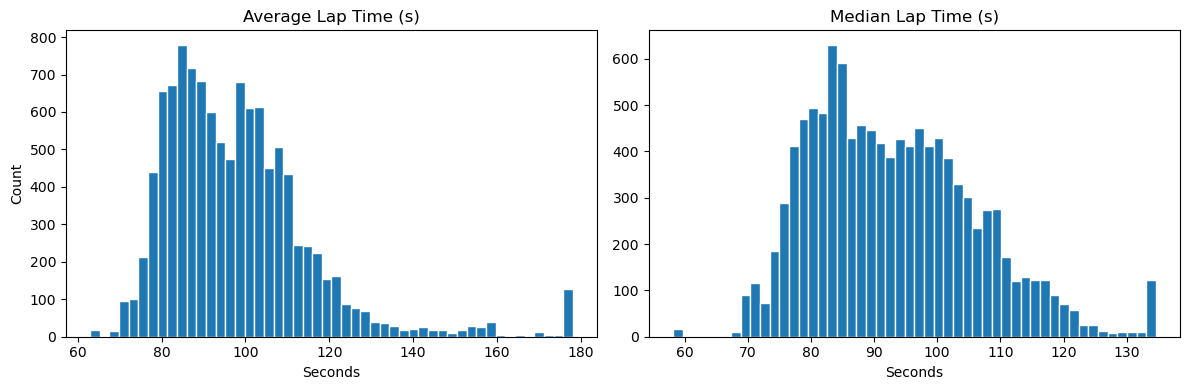

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Average Lap Time
series = feature_table["avg_lap_time_sec"]
lower = series.quantile(0.0)
upper = series.quantile(0.99)

axes[0].hist(
    series.clip(lower, upper).dropna(),
    bins=50,
    edgecolor="white"
)
axes[0].set_title("Average Lap Time (s)")
axes[0].set_xlabel("Seconds")
axes[0].set_ylabel("Count")

# Median Lap Time
series = feature_table["median_lap_time_sec"]
lower = series.quantile(0.0)
upper = series.quantile(0.99)

axes[1].hist(
    series.clip(lower, upper).dropna(),
    bins=50,
    edgecolor="white"
)
axes[1].set_title("Median Lap Time (s)")
axes[1].set_xlabel("Seconds")

plt.tight_layout()
plt.show()


#### Insight — Average Lap Time

- Most driver–race average lap times are between **~75–110 seconds**, representing typical race pace.  
- The distribution is **right-skewed**, with a long tail of slower races caused by unusual conditions.

#### Insight — Median Lap Time

- Median lap times are tightly clustered between **~75–105 seconds**, reflecting stable and typical race pace.  
- Compared to average lap time, the distribution is **less skewed** and less affected by extreme laps, making median lap time a more robust measure of performance.


#### Lap Time Variability

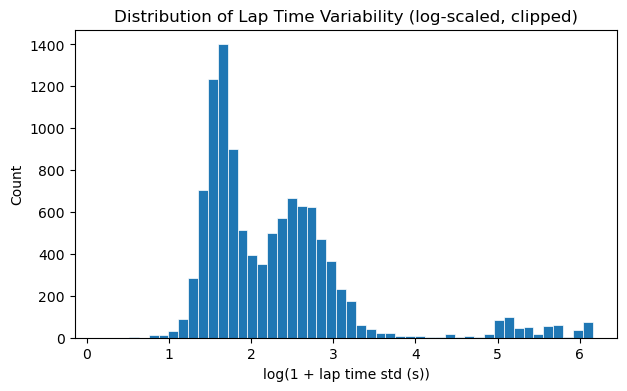

In [22]:
# Lap time variability (standard deviation)
# Heavy right tail → apply percentile clipping + log transform for visualization
series = feature_table["std_lap_time_sec"]

# Clip extreme upper tail
upper = series.quantile(0.995)
x = series.clip(0, upper).dropna()

# Log transform to compress tail
x_log = np.log1p(x)

plt.figure(figsize=(7, 4))
plt.hist(x_log, bins=50, edgecolor="white", linewidth=0.5)
plt.title("Distribution of Lap Time Variability (log-scaled, clipped)")
plt.xlabel("log(1 + lap time std (s))")
plt.ylabel("Count")
plt.show()


#### Insight

- Most driver–race entries show **low lap time variability**, indicating generally stable and consistent pace.
- A smaller concentration appears at **moderate variability**, likely reflecting traffic, strategy changes, or mild instability.
- A **long right tail** remains even after clipping, highlighting rare races with **highly unstable lap times**.
- This confirms that lap time variability is **strongly right-skewed**, justifying log transformation and scaling before modeling.


#### Distribution of Pace Drop

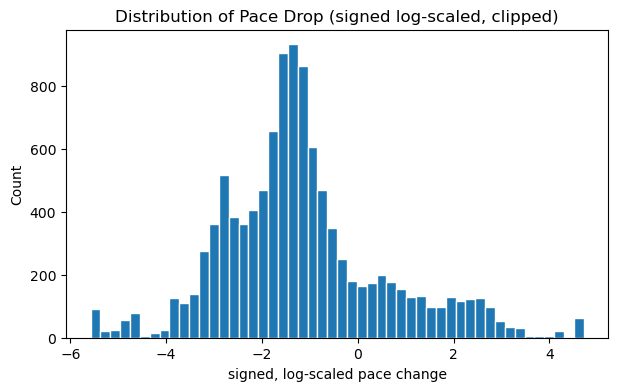

In [23]:
# Pace drop distribution
# Values can be positive (slowing down) or negative (speeding up)
series = feature_table["pace_drop_sec"]

# Symmetric percentile clipping
lower = series.quantile(0.005)
upper = series.quantile(0.995)
x = series.clip(lower, upper).dropna()

# Signed log transform preserves direction while compressing extremes
x_signed_log = np.sign(x) * np.log1p(np.abs(x))

plt.figure(figsize=(7, 4))
plt.hist(x_signed_log, bins=50, edgecolor="white")
plt.title("Distribution of Pace Drop (signed log-scaled, clipped)")
plt.xlabel("signed, log-scaled pace change")
plt.ylabel("Count")
plt.show()


#### Insight

- The distribution is centered slightly **below zero**, indicating that many drivers become **faster later in the race** (fuel burn-off effect).
- Negative values represent **pace improvement**, while positive values indicate **performance degradation**.
- A long tail on both sides shows **rare but extreme pace changes**, often linked to damage, strategy shifts, or retirements.

#### Feature Relationships
 **Unusual combinations of features**, not just extreme values.

Anomalies often:
- are **not extreme in a single feature**
- but arise from **unexpected combinations of otherwise normal values**


#### Consistency  vs Pace Degradation

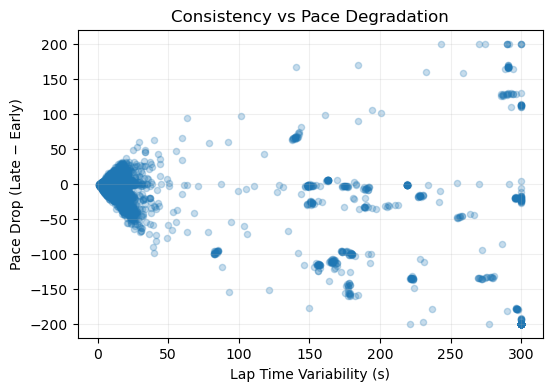

In [25]:
plt.figure(figsize=(6,4))
plt.scatter(
    feature_table["std_lap_time_sec"].clip(upper=300),
    feature_table["pace_drop_sec"].clip(-200, 200),
    alpha=0.25,
    s=20
)

plt.xlabel("Lap Time Variability (s)")
plt.ylabel("Pace Drop (Late − Early)")
plt.title("Consistency vs Pace Degradation")
plt.grid(alpha=0.2)
plt.show()


#### Insight
This plot highlights **unusual combinations of race behavior**, not just extreme values.

- Most races cluster at **low lap time variability** with **small pace changes**, representing normal, stable performances.
- Races with **high lap time variability and large pace drops** indicate chaotic events, often linked to incidents, damage, or strategy disruption.
- Races with **low variability but strong pace degradation** suggest unusual performance decline despite otherwise consistent laps.

These regions contain behaviors that are not extreme in a single feature, but are **anomalous due to their combination**, making them well suited for multivariate anomaly detection.


#### Correlation Heatmap

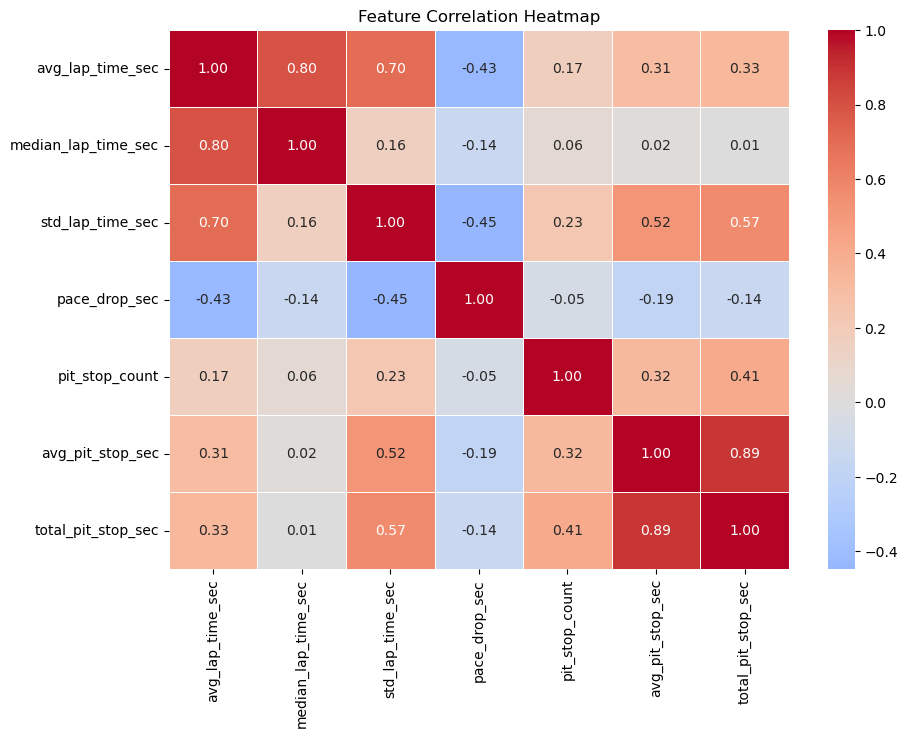

In [26]:
eda_corr_features = [
    "avg_lap_time_sec",
    "median_lap_time_sec",
    "std_lap_time_sec",
    "pace_drop_sec",
    "pit_stop_count",
    "avg_pit_stop_sec",
    "total_pit_stop_sec",
]

corr = feature_table[eda_corr_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,       
    fmt=".2f",  
    linewidths=0.5 
)
plt.title("Feature Correlation Heatmap")
plt.show()


#### Insights

- The correlation heatmap shows that some features naturally move together, while others capture distinct aspects of race behavior.

- Lap time features (`avg_lap_time_sec`, `median_lap_time_sec`, `std_lap_time_sec`) are **strongly correlated**, which is expected since they describe **overall race pace and consistency**. Slower races tend to also show higher lap time variability.

- Pit stop timing features (`avg_pit_stop_sec` and `total_pit_stop_sec`) have **very strong correlation**, indicating they describe the same pit stop behavior from different perspectives. This confirms **pit performance is a clear and consistent signal**.

- In contrast, `pace_drop_sec` shows **moderate negative correlation with lap time features**, meaning **pace degradation captures dynamic race behavior rather than absolute speed**. This makes it a valuable and complementary feature for detecting anomalies.

- Overall, the feature set contains both related and independent signals, providing a balanced representation of pace, consistency, degradation, and strategy suitable for anomaly detection.


C:\Users\saral\AppData\Local\Temp\ipykernel_41652\3686111105.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


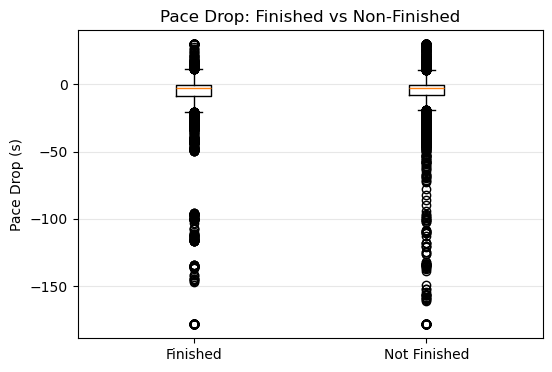

In [27]:
finished = feature_table.loc[
    feature_table["statusId"] == 1,
    "pace_drop_sec"
]

not_finished = feature_table.loc[
    feature_table["statusId"] != 1,
    "pace_drop_sec"
]

low = feature_table["pace_drop_sec"].quantile(0.01)
high = feature_table["pace_drop_sec"].quantile(0.99)

plt.figure(figsize=(6,4))
plt.boxplot(
    [
        finished.clip(low, high).dropna(),
        not_finished.clip(low, high).dropna()
    ],
    labels=["Finished", "Not Finished"]
)
plt.ylabel("Pace Drop (s)")
plt.grid(axis="y", alpha=0.3)
plt.title("Pace Drop: Finished vs Non-Finished")
plt.show()


#### Insights

- **Finished races** show small pace changes centered near zero, indicating stable performance throughout the race.

- **Non-finished races (DNFs)** display much wider variation and many extreme pace changes, reflecting instability before retirement.

- This clear separation shows that **pace_drop captures abnormal race behavior**, not just random noise.

- As a result, **pace drop is a meaningful and reliable feature for anomaly detection**, helping distinguish normal completed races from problematic ones.


## Phase 5 - Modeling Preparation

Before applying anomaly detection models, the engineered features are scaled to ensure that variables with different units and magnitudes contribute appropriately to distance-based and projection-based methods.


### Scaling

The transformations applied here are designed to:
- reduce the influence of heavy-tailed distributions
- preserve directional information where relevant
- prepare a numerically stable feature space for unsupervised modeling

In [28]:
from sklearn.preprocessing import StandardScaler

# Select features for modeling
features_for_model = [
    "starting_grid_position",
    "completed_laps",
    "lap_count",
    "avg_lap_time_sec",
    "median_lap_time_sec",
    "std_lap_time_sec",
    "pace_drop_sec",
    "pit_stop_count",
    "avg_pit_stop_sec",
    "total_pit_stop_sec",
]

df = feature_table[features_for_model].copy()

# Binary indicator: did the driver pit at least once?
df["has_pit_stop"] = (df["pit_stop_count"] > 0).astype(int)

# Log transforms for heavy-tailed positive features
# Compress extreme values, make extreme races less dominant
log_cols = [
    "avg_lap_time_sec",
    "median_lap_time_sec",
    "std_lap_time_sec",
    "avg_pit_stop_sec",
    "total_pit_stop_sec",
]
for col in log_cols:
    df[col] = np.log1p(df[col].clip(lower=0))

# Signed log transform for pace drop
# (preserves direction: slowing down vs speeding up)
df["pace_drop_sec"] = np.sign(df["pace_drop_sec"]) * np.log1p(np.abs(df["pace_drop_sec"]))

# Handle missing values
# Median imputation is robust and suitable for unsupervised learning
df = df.fillna(df.median(numeric_only=True))

# Standard scaling (mean = 0, std = 1)
cols_to_scale = [
    "starting_grid_position",
    "completed_laps",
    "lap_count",
    "pit_stop_count",
    "avg_lap_time_sec",
    "median_lap_time_sec",
    "std_lap_time_sec",
    "pace_drop_sec",
    "avg_pit_stop_sec",
    "total_pit_stop_sec",
    "has_pit_stop", 
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cols_to_scale])
X_scaled = pd.DataFrame(X_scaled, columns=cols_to_scale, index=df.index)


### Why These Features Matter

- Capture **how the race unfolded**, not just the final result  
- Starting position provides context for expected performance  
- Completion metrics highlight **DNFs and early retirements**  
- Lap time features describe **pace and consistency**  
- Pace drop reflects **performance evolution** during the race  
- Pit stop features capture **strategy, interruptions, and technical issues**  
- Together, they form a **compact representation of normal vs abnormal race behavior** for anomaly detection


### Dimensionality Reduction with PCA

Before applying anomaly detection models, we use **Principal Component Analysis (PCA)** to better understand the overall structure of race behavior in the data.

PCA helps reduce many features into a smaller number of components that capture most of the variation between races. This step is **exploratory** and is **not used directly to detect anomalies**. Instead, it allows us to:

- see whether race behavior can be described in fewer dimensions,
- visualize the data in 2D or 3D,
- gain intuition about what “normal” and “unusual” races look like.

All features used in PCA were previously transformed and standardized so that no single feature dominates the analysis.



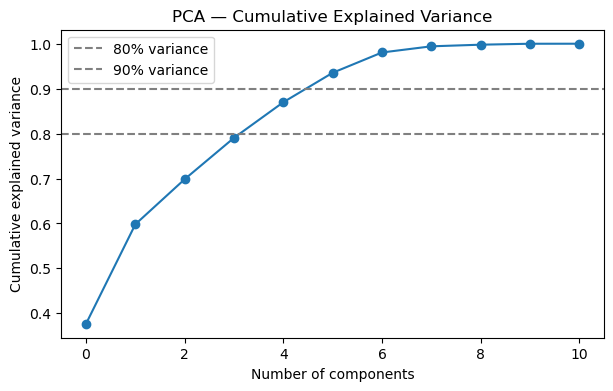

In [30]:
from sklearn.decomposition import PCA

# Fit PCA on scaled features
pca = PCA()
X_pca = pca.fit_transform(X_scaled) # data expressed in the new directions

# How much variance (information) each component explains
explained_var = pca.explained_variance_ratio_

# If I keep first k components, how much total behavior do I capture?
cum_explained_var = np.cumsum(explained_var)

plt.figure(figsize=(7, 4))
plt.plot(cum_explained_var, marker="o")
plt.axhline(0.8, linestyle="--", color="gray", label="80% variance")
plt.axhline(0.9, linestyle="--", color="gray", label="90% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.show()



### Principal Component Analysis (PCA)

Each principal component is a new axis created from combinations of the original features.  
Components are ordered from most important to least important, based on how much variance they explain.

PCA learns the directions where the data varies the most.

- **X-axis** → number of PCA components kept  
- **Y-axis** →  how much of original data variance explained

#### Explained Variance Interpretation

The cumulative explained variance shows that Formula 1 race behavior can be summarized using a small number of components.

- The **first component** explains around **38%** of the **total variance**, capturing a large part of race behavior.
- The first **two components** explain roughly **60%** of the **variance**, which is more than half of the race behavior.
- The first **four components** explain around **80%** of the total variance.
- **Five components** capture close to **90%** of the **variance**.

After six components, the curve flattens, meaning additional components contribute very little new information.

#### Key Insights

- The feature space is not random.
- Many features are correlated and redundant.
- Formula 1 race behavior lies in a **low-dimensional structure**.

PCA provides a compact and interpretable view of the data, supporting subsequent anomaly detection.

#### Why This Helps Anomaly Detection

- Noise is reduced.
- Redundant information is removed.
- Anomalies are easier to detect in a compact feature space.

For **distance-based anomaly detection**, keeping **4–5 principal components** is sufficient.

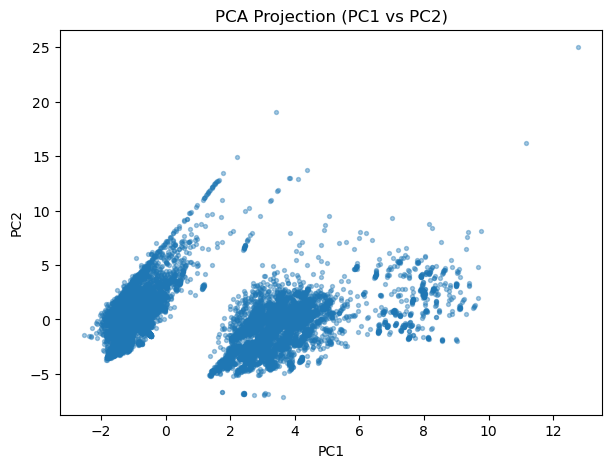

In [31]:
# 2D PCA visualization
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (PC1 vs PC2)")
plt.show()

### PCA 2D Projection — Race Behavior Overview

This plot shows each race projected into a 2D space that captures the **two main ways races differ from each other**.

Races differ in many aspects, but **not all differences are equally important**.  
PCA keeps only the most meaningful sources of variation.

---

#### How to Read the Plot

- **Each point** → one *race × driver* instance  
- **Distance between points**  
  - close → similar race behavior  
  - far apart → very different race behavior  

- **Dense areas** → typical / normal races  
- **Isolated points** → potential anomalies

Clear grouping and structure indicate that **races do not all behave the same way**.

---

#### Interpreting the Principal Components

- **PC1 (x-axis)**  
  The dominant source of variation.  
  Most of the separation happens horizontally, showing that PC1 drives the largest differences between races.  

- **PC2 (y-axis)**  
  Captures secondary effects.

---

#### Key Insights

- The presence of **multiple dense regions** suggests several *normal race regimes*, not a single “typical” race.
- These regimes likely correspond to:
  - different pit strategies  
  - different pace dynamics  
  - different lap counts  

- A small number of points lie far from the main clusters, highlighting **potential anomalous races**.

---
This visualization provides strong qualitative evidence that the anomaly detection results are meaningful rather than random.


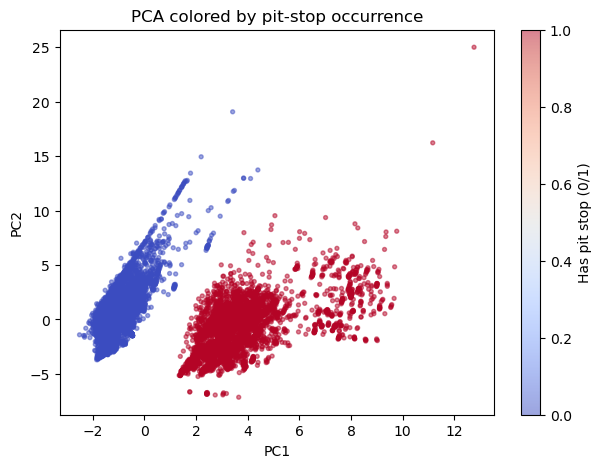

In [32]:
# PCA colored by pit-stop behavior

plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["has_pit_stop"],
    cmap="coolwarm",
    s=8,
    alpha=0.5
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA colored by pit-stop occurrence")
plt.colorbar(label="Has pit stop (0/1)")
plt.show()

### PCA Colored by Pit Stop Behavior

This visualization helps answer an important question:  
**Does pit stop behavior explain part of the PCA structure?**

---

#### What We Observe

Two clearly separated regions:

- **Blue points cluster on the left**
- **Red points cluster on the right**

This strong separation indicates that **pit stop behavior is a major driver of variation in race behavior**.

---

#### Interpreting the Axes

- **PC1 (x-axis)**  
  Most of the separation happens along this axis.
  - Left side → mostly races with **no pit stops**
  - Right side → mostly races **with pit stops**

  This suggests that PC1 captures:
  - pit stop involvement  
  - strategy complexity  
  - race intervention and flow changes  

  This explains why PC1 is the **largest source of variance** in the data.

- **PC2 (y-axis)**  
  Points spread vertically within both blue and red groups.
  - Some no-pit races are smooth, others are chaotic  
  - Some pit-stop races are clean, others are messy  

  PC2 therefore captures:
  - variability in pace  
  - race instability  
  - overall race chaos  

---

In [33]:
# PCA loadings

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_scaled.columns,
    columns=[f"PC{i+1}" for i in range(X_scaled.shape[1])]
)

loadings.iloc[:, :2]

,PC1,PC2
starting_grid_position,-0.009687,0.054842
completed_laps,0.093235,-0.286985
lap_count,0.017186,-0.464381
pit_stop_count,0.451588,-0.106534
avg_lap_time_sec,0.197394,0.542544
median_lap_time_sec,0.115457,0.536511
std_lap_time_sec,0.250420,0.232549
pace_drop_sec,-0.079405,-0.121319
avg_pit_stop_sec,0.474924,-0.095699
total_pit_stop_sec,0.480505,-0.096875


### PCA Loadings

Inspecting the PCA loadings shows that each principal component is driven by a **clear and interpretable group of features**, rather than random noise.

Each value indicates **how strongly an original feature contributes** to a principal component.  
The **magnitude** of the value matters most — the sign only indicates direction along the axis and does not affect importance.

---

#### PC1 — Pit Strategy and Race Complexity

PC1 is **dominated by pit-related features**, all contributing above 40%, with additional influence from lap-time variability.

This matches what was observed in the PCA scatter plots and explains why PC1 is the **largest source of variance**.

---

#### PC2 — Overall Race Pace vs Race Length

PC2 contrasts **lap-time speed and variability** against **race length and completion**.

**High PC2 values**
- Point appears **higher on the plot** (upper part of the y-axis)
- PC2 value is **positive and large**
- Race characteristics:
  - slower average lap times
  - fewer laps completed

**Low PC2 values**
- Point appears **lower on the plot** (lower part of the y-axis)
- PC2 value is **negative or small**
- Race characteristics:
  - more laps completed
  - more stable and consistent pace

PC2 therefore captures **pace characteristics**, not pit strategy.  
Positive and negative values simply reflect **opposite ends of the same behavioral spectrum**.

---
These results show that PCA did **not mix unrelated features**:
- Each principal component has a clear behavioral meaning
- Features are semantically coherent and well engineered
- The components align with domain knowledge of Formula 1 racing


## Phase 6 - Anomaly Detection / Scoring

### Distance-based Anomaly Scoring (PCA Space)

PCA reveals where **normal races naturally cluster** in a reduced, noise-filtered feature space.

Races that lie **far from the center of this space** exhibit unusual behavior.

Here, distance answers a simple question:

> **“How different is this race compared to typical race behavior?”**

This approach does **not perform clustering** or assign group labels.  
It purely measures **distance from normality**, making it a simple and interpretable anomaly scoring method.

In [34]:
from numpy.linalg import norm

# Base dataframe for anomaly results
df_anomaly = feature_table.copy()

# Use the first k PCA components
k = 4
X_pca_k = X_pca[:, :k]

# Define the "normal race center"
# This represents the average race behavior in PCA space
pca_center = X_pca_k.mean(axis=0)

# Compute Euclidean distance from the center
# How far a race is from typical behavior
pca_distance = norm(X_pca_k - pca_center, axis=1)

# Each race now has:
# 1. small distance → very normal
# 2. large distance → very unusual

# Standardize distances to make them easier to compare
pca_anomaly_score = (pca_distance - pca_distance.mean()) / pca_distance.std()
# Higher score = more anomalous.

# Attach results to dataframe
df_anomaly["pca_distance"] = pca_distance
df_anomaly["pca_anomaly_score"] = pca_anomaly_score


### Isolation Forest

Isolation Forest answers a simple question:

> **“Is this race easy or hard to isolate from the rest?”**

It works by repeatedly making random splits in the feature space.

- **Normal races** → need many splits to isolate → they blend in with others  
- **Unusual races** → get isolated quickly → they stand out

Isolation Forest assigns an anomaly score to each race based on **how easily it can be separated** from the rest of the data. Races that are isolated early in the tree structure receive higher anomaly scores and are considered anomalous.

This method is well suited for **complex, high-dimensional race behavior** and serves as a strong and flexible anomaly detection model.


In [35]:
from sklearn.ensemble import IsolationForest

# Fit Isolation Forest
iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.02,  # top 2%
    random_state=42
)

iso_forest.fit(X_scaled)

# Get anomaly scores

# Raw scores (higher = more normal)
iso_scores = iso_forest.decision_function(X_scaled)

# Convert so higher = more anomalous
iso_anomaly_score = -iso_scores

# Flag anomalies

# Predict anomalies (-1 = anomaly, 1 = normal)
iso_labels = iso_forest.predict(X_scaled)

# Attach results to anomaly dataframe
df_anomaly["iso_anomaly_score"] = iso_anomaly_score
df_anomaly["iso_is_anomaly"] = (iso_labels == -1).astype(int)


#### Anomaly Score Distribution Summary

In [36]:
df_anomaly[[
    "pca_anomaly_score",
    "iso_anomaly_score",
    "iso_is_anomaly"
]].describe()

,pca_anomaly_score,iso_anomaly_score,iso_is_anomaly
count,2.675900e+04,26759.000000,26759.000000
mean,-1.699418e-17,-0.235179,0.020031
std,1.000019e+00,0.090767,0.140108
min,-9.718833e-01,-0.320222,0.000000
25%,-7.089703e-01,-0.309126,0.000000
50%,-3.769481e-01,-0.284514,0.000000
75%,4.857663e-01,-0.158755,0.000000
max,1.559825e+01,0.114410,1.000000


#### Insights
The PCA-based anomaly scores are centered around zero, with most races clustered near typical behavior and a small number of extreme values on both ends. This indicates that while the majority of races follow common race patterns, a few races deviate strongly and stand out as unusual.

Isolation Forest produces a tighter score distribution and flags approximately **2% of races as anomalous**, which matches the specified contamination level. These flagged races represent rare and extreme behaviors that are easy to isolate from the rest of the data.

#### Why Using Both Methods Is Good Practice

Using both PCA-distance scoring and Isolation Forest provides complementary perspectives on race anomalies.

- **PCA distance**  
  Measures global deviation from typical race behavior in a reduced and interpretable feature space.  
  It captures gradual and continuous deviations from the norm.

- **Isolation Forest**  
  Focuses on rare, complex, and non-linear patterns that are easy to isolate but may not be extreme in Euclidean distance.

Together, these methods ensure that anomalies are not missed due to assumptions about linearity or distance alone. Their agreement strengthens confidence in the detected anomalous races.


### Comparison of Anomaly Counts: PCA Distance vs Isolation Forest


In [37]:
# Flag top 2% anomalies
threshold = df_anomaly["pca_anomaly_score"].quantile(0.98)

df_anomaly["pca_is_anomaly"] = (
    df_anomaly["pca_anomaly_score"] >= threshold
).astype(int)

df_anomaly["pca_is_anomaly"].value_counts()

pca_is_anomaly
0    26223
1      536
Name: count, dtype: int64

In [38]:
# Isolation Forest anomalies
df_anomaly["iso_is_anomaly"].value_counts()


iso_is_anomaly
0    26223
1      536
Name: count, dtype: int64

#### Overlap Analysis Between PCA-Distance and Isolation Forest Anomalies

In [39]:
pd.crosstab(
    df_anomaly["pca_is_anomaly"],
    df_anomaly["iso_is_anomaly"],
    rownames=["PCA anomaly"],
    colnames=["Isolation Forest anomaly"]
)

Isolation Forest anomaly,0,1
PCA anomaly,,
0,26160,63
1,63,473


#### Insight

This analysis compares which races are flagged as anomalous by PCA-distance scoring and Isolation Forest.

- **473 races** are flagged as anomalies by **both methods**.  
  These are the **strongest and most reliable anomalies**, where both approaches agree that race behavior is unusual.

- **26,160 races** are considered normal by both methods, showing that most races follow typical behavior.

- **63 races** are flagged only by PCA-distance.  
  These races are far from the average race profile but still follow consistent patterns (for example, races with heavy pit involvement). This is expected for distance-based methods.

- **63 races** are flagged only by Isolation Forest.  
  These races contain rare or unusual feature combinations that are not extreme in PCA space. This shows how Isolation Forest captures patterns that PCA can miss.

Both methods flag about **2% of races** as anomalous, and around **88% of detected anomalies overlap**. This strong agreement confirms that the methods complement each other and together provide a reliable way to detect unusual race behavior.


#### Visualize anomalies in PCA space

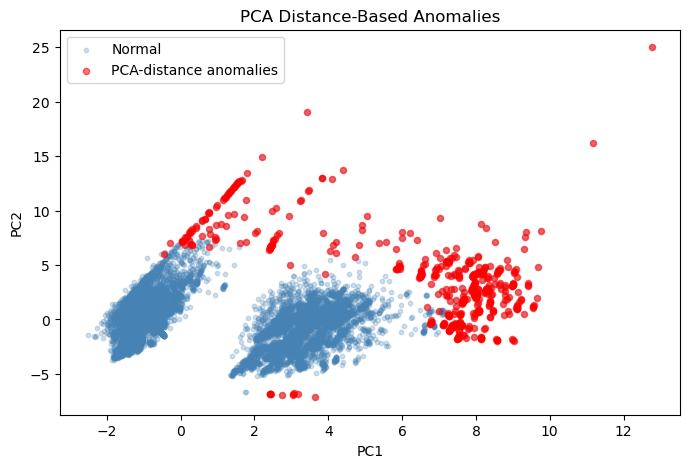

In [40]:
plt.figure(figsize=(8, 5))

# Normal races
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c="steelblue",
    s=10,
    alpha=0.25,
    label="Normal",
    zorder=1
)

# PCA anomalies
plt.scatter(
    X_pca[df_anomaly["pca_is_anomaly"] == 1, 0],
    X_pca[df_anomaly["pca_is_anomaly"] == 1, 1],
    c="red",
    s=20,       
    alpha=0.55,
    label="PCA-distance anomalies",
    zorder=2
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Distance-Based Anomalies")
plt.legend()
plt.show()


#### Insight
- Most races form **dense clusters**, showing consistent and repeatable race behavior.
- Normal races are tightly grouped, indicating common patterns.
- Anomalies (red points) lie **far from these clusters**.
- Separation is mainly along **PC1**, linked to pit involvement and race complexity.
- Some anomalies extend along **PC2**, reflecting chaotic or unstable race dynamics.
- This confirms that PCA-distance clearly separates typical races from **rare, extreme behaviors**.


#### Distribution of PCA distances 

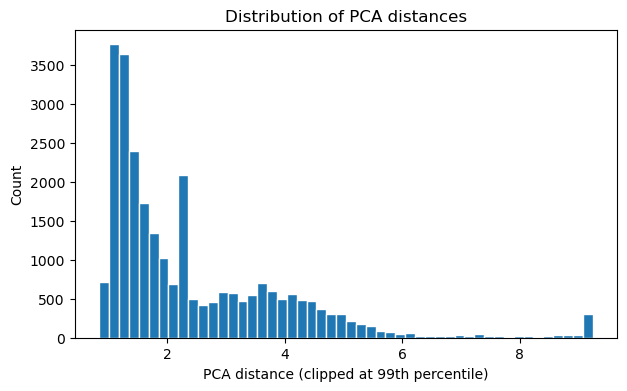

In [41]:
upper = df_anomaly["pca_distance"].quantile(0.99)

plt.figure(figsize=(7, 4))
plt.hist(df_anomaly["pca_distance"].clip(upper=upper), bins=50, edgecolor="white")
plt.xlabel("PCA distance (clipped at 99th percentile)")
plt.ylabel("Count")
plt.title("Distribution of PCA distances")
plt.show()


#### Insight

- Most races have **low PCA distances**, meaning their behavior is close to normal.
- The dense peak represents common race patterns (similar pace, pit behavior, race length).
- As PCA distance increases, the number of races drops, forming a **long right tail**.
- The tail shows races that increasingly deviate from typical behavior.
- A small number of races at the upper end indicate **rare but strong anomalies**.


### Phase 7  - Model Evaluation & Validation

#### Post-hoc Validation (Status / DNF Check)
**Goal:** Confirm that the strongest anomalies correspond to real unusual race outcomes (DNF, collisions, mechanical failures), not random noise.


In [42]:
# Flag PCA anomalies (top 2% by PCA-distance score)
pca_thresh = df_anomaly["pca_anomaly_score"].quantile(0.98)
df_anomaly["pca_is_anomaly"] = (df_anomaly["pca_anomaly_score"] >= pca_thresh).astype(int)

# Shared anomalies = PCA AND Isolation Forest
both_anomalies = df_anomaly[
    (df_anomaly["pca_is_anomaly"] == 1) &
    (df_anomaly["iso_is_anomaly"] == 1)
].copy()

 
# Merge status text + race info + driver info
both_anomalies = both_anomalies.merge(
    status[["statusId", "status"]],
    on="statusId",
    how="left"
)

both_anomalies = both_anomalies.merge(
    races[["raceId", "year", "race_name"]],
    on="raceId",
    how="left"
)

both_anomalies = both_anomalies.merge(
    drivers[["driverId", "first_name", "surname"]],
    on="driverId",
    how="left"
)

both_anomalies["driver_name"] = (
    both_anomalies["first_name"].fillna("") + " " + both_anomalies["surname"].fillna("")
).str.strip()

# If merges created duplicate year columns (year_x/year_y), keep the race year
if "year_x" in both_anomalies.columns and "year_y" in both_anomalies.columns:
    both_anomalies = both_anomalies.drop(columns=["year_x"]).rename(columns={"year_y": "year"})

# Show top 10 (most anomalous)
both_anomalies = both_anomalies.sort_values("iso_anomaly_score", ascending=False)

cols_show = [
    "year", "race_name", "driver_name",
    "status",
    "starting_grid_position", "finish_position",
    "completed_laps", "pit_stop_count",
    "avg_lap_time_sec", "std_lap_time_sec", "pace_drop_sec",
    "total_pit_stop_sec",
    "pca_anomaly_score", "iso_anomaly_score"
]

both_anomalies[cols_show].head(10)


,year,race_name,driver_name,status,starting_grid_position,finish_position,completed_laps,pit_stop_count,avg_lap_time_sec,std_lap_time_sec,pace_drop_sec,total_pit_stop_sec,pca_anomaly_score,iso_anomaly_score
418,2023,Japanese Grand Prix,Sergio Pérez,Collision damage,5,19,15,4,292.526200,636.135336,602.833583,2590.513,6.644479,0.114410
296,2021,Hungarian Grand Prix,Nikita Mazepin,Collision,19,14,3,2,631.957667,811.560809,NaN,1481.135,10.513697,0.105109
143,2016,Italian Grand Prix,Felipe Nasr,Collision damage,18,22,6,3,255.096167,323.524447,429.192500,874.834,6.294013,0.103620
229,2020,Bahrain Grand Prix,Lance Stroll,Collision,13,19,2,1,753.493000,831.113512,NaN,1154.123,15.598248,0.099527
454,2024,Japanese Grand Prix,Guanyu Zhou,Gearbox,20,18,12,3,247.418500,458.143093,-568.660833,1633.475,6.393951,0.089916
336,2021,Saudi Arabian Grand Prix,Nikita Mazepin,Collision,20,18,14,1,194.647714,290.040064,322.008500,1019.226,4.628482,0.088664
394,2023,Australian Grand Prix,Valtteri Bottas,Finished,0,11,58,6,158.015241,292.369523,108.931786,3662.236,4.395414,0.084610
179,2017,Azerbaijan Grand Prix,Nico Hülkenberg,Accident,13,17,24,3,190.867500,274.398183,236.652238,1350.542,5.062916,0.084205
178,2017,Azerbaijan Grand Prix,Felipe Massa,Suspension,9,16,25,3,188.396520,270.080522,232.528524,1347.157,5.029713,0.082392
365,2022,British Grand Prix,Valtteri Bottas,Gearbox,12,17,20,1,256.319250,693.140085,-640.708800,3055.732,6.436032,0.080719


#### Insight
- The strongest shared anomalies are dominated by **abnormal race statuses** such as *Collision*, *Accident*, *Gearbox*, and *Suspension*.
- These outcomes naturally produce extreme behavior: **few completed laps**, **irregular lap times**, and **unusual pit activity**.
- This alignment between anomaly scores and real race incidents acts as a strong **sanity check** for the models.
- We also detect a **“Finished”** status race, it suggests extreme strategies or unusual race dynamics rather than failures.
- Overall, this validation confirms that the detected anomalies reflect **real and meaningful race events**, not modeling artifacts.


#### Anomaly vs Normal Behavior Race Comparison

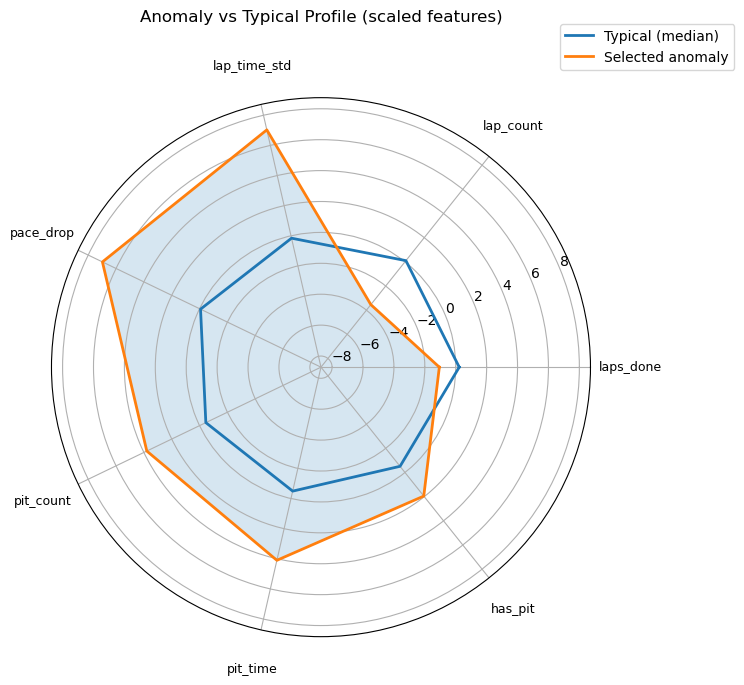

In [44]:
from math import pi

# Use the same columns you scaled
radar_features = [
    "completed_laps",
    "lap_count",
    "std_lap_time_sec",
    "pace_drop_sec",
    "pit_stop_count",
    "total_pit_stop_sec",
    "has_pit_stop"
]

# Display labels
labels = ["laps_done", "lap_count", "lap_time_std", "pace_drop", "pit_count", "pit_time", "has_pit"]

# Typical race behavior
typical = X_scaled[radar_features].median()

# Pick one case - most anomalous by Isolation Forest
idx = df_anomaly["iso_anomaly_score"].idxmax() # row index with largest score
anomaly = X_scaled.loc[idx, radar_features] # take the feature values from that row

# Fit the features evenly in the circle space
angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist() # endpoint=False stop before 2π to avoid duplicates 
# Take the first angle again so that the line closes the loop
angles += angles[:1]

# Values must close the loop so we return to the first value 
vals_typical = typical.tolist() + [typical.iloc[0]]
vals_anom = anomaly.tolist() + [anomaly.iloc[0]]

# How far should the plot extend? (Max value)
max_abs = np.abs(X_scaled[radar_features]).to_numpy().max()
r_lim = max_abs * 1.05

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

# Lines
ax.plot(angles, vals_typical, linewidth=2, label="Typical (median)")
ax.plot(angles, vals_anom, linewidth=2, label="Selected anomaly")
ax.fill(angles, vals_anom, alpha=0.18)

# Set symmetric radial limits so negative/positive are visually consistent
ax.set_ylim(-r_lim, r_lim)

# X labels + spacing so the top label doesn't collide with the title
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.tick_params(axis="x", pad=18)

# Title higher (pad) so it doesn't overlap top labels
ax.set_title("Anomaly vs Typical Profile (scaled features)", pad=55)

# Legend placement
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.15))
plt.show()


#### Insight

This radar chart compares a **typical race** (median of all races) with a **selected anomalous race** using **scaled features** (mean = 0, std = 1).  
Each axis shows how far a feature deviates from normal race behavior.

- **Center** → typical race behavior  
- **Farther from center** → more unusual behavior  
- **Blue line** → typical (median) race  
- **Orange line** → anomalous race  

This race is not extreme in just one feature.  
It shows **multiple deviations at the same time**, which is exactly what anomaly detection aims to identify.

- Explains *why* the model flagged a race as anomalous  
- Makes anomaly detection interpretable and intuitive  
- Connects model output to real race behavior  


## Final Insights & Conclusions

### What did we learn?

- Formula 1 race behavior follows **clear, structured patterns** rather than random variation.
- A small number of factors — **pit involvement, race length, pace stability, and performance changes** — explain most of the variability between races.
- Most races behave similarly and form dense clusters, while a **small minority deviate strongly** from typical race dynamics.
- These deviations correspond to real events such as **collisions, mechanical failures, extreme strategies, and chaotic race conditions**.

### Why does this matter?

- Anomaly detection highlights races that deserve deeper analysis, even when a driver technically finishes the race.
- This approach enables **systematic identification of rare events** without relying on predefined labels or subjective rules.
- The methodology can support performance analysis, strategy evaluation, and exploratory race analytics at scale.

### Why is the approach valid?

- PCA provides an interpretable, low-dimensional representation of race behavior and confirms that the engineered features capture meaningful structure.
- PCA-distance and Isolation Forest detect anomalies using **complementary principles**:
  - PCA-distance captures **global deviation from typical behavior**.
  - Isolation Forest captures **locally rare and non-linear patterns**.
- The strong overlap between both methods demonstrates robustness, while disagreements reveal different definitions of abnormality rather than errors.
- Post-hoc validation using race status, DNFs, and case studies confirms that detected anomalies align with real race incidents.

### Final Conclusion
This project demonstrates that unsupervised learning can effectively uncover rare and meaningful race behaviors in Formula 1 data. By combining interpretable dimensionality reduction, complementary anomaly detection methods, and domain-based validation, the analysis identifies both obvious failures and subtle strategic anomalies. The results confirm that race behavior is structured, anomalies are rare but significant, and unsupervised models can provide valuable insights without labeled outcomes.
